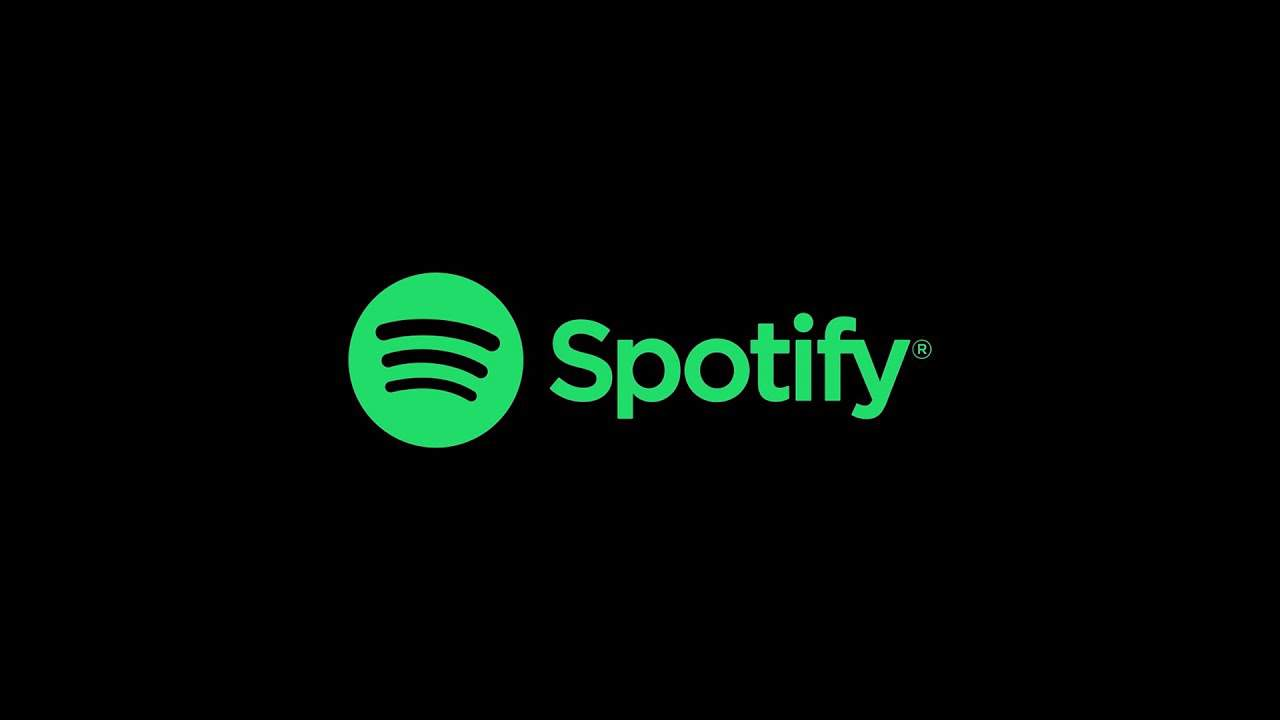
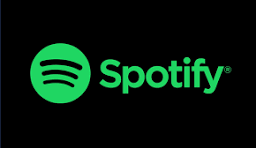
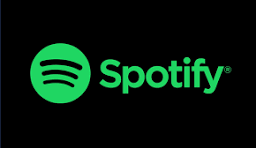
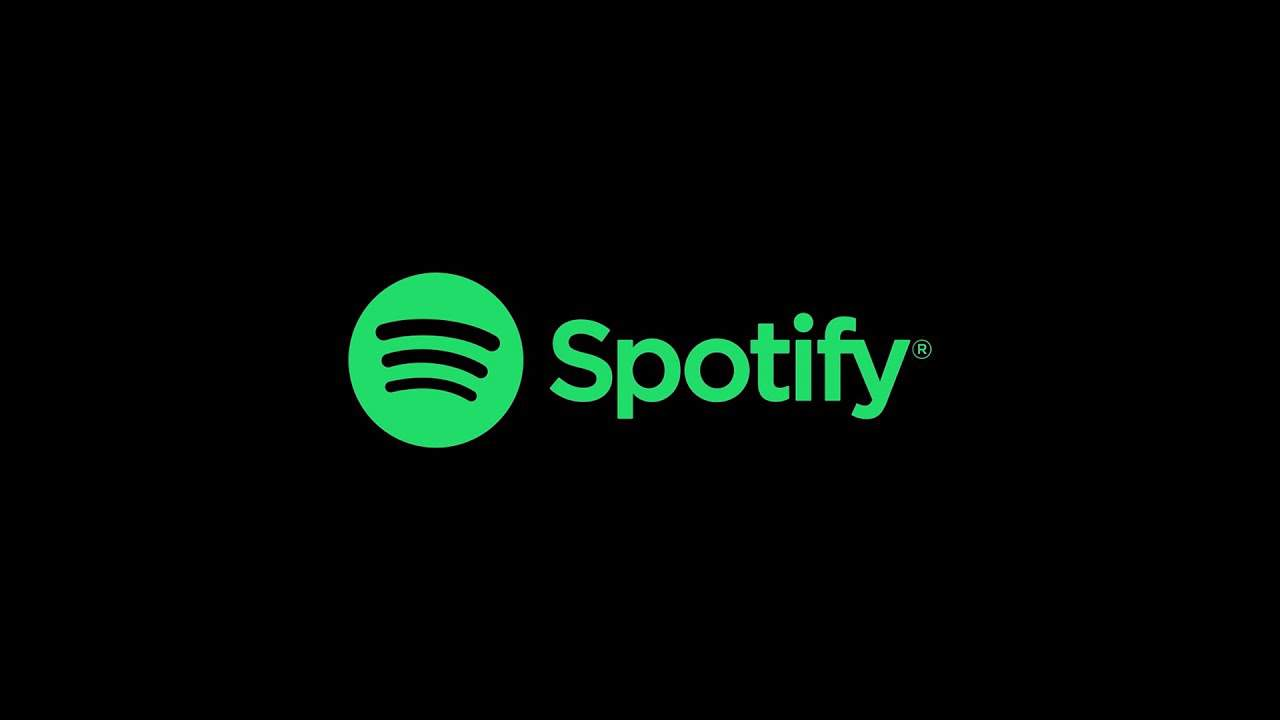

# 🎧 **Spotify User Churn Analysis**

# 📌 Introduction

Understanding why users stop using Spotify is essential for improving user retention and increasing revenue. This project analyzes user listening behavior, engagement patterns, and subscription types to identify churn indicators and predict users at risk of leaving.

# 📂 Import Libraries

In [137]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 📊 Load Dataset

In [138]:
df = pd.read_csv("/kaggle/input/datasets/nabihazahid/spotify-dataset-for-churn-analysis/spotify_churn_dataset.csv")

In [139]:
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


# 🔍  Data Overview

In [140]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [142]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


# 🧹 Data Cleaning

In [143]:
# Checking Null Values
df.isnull().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

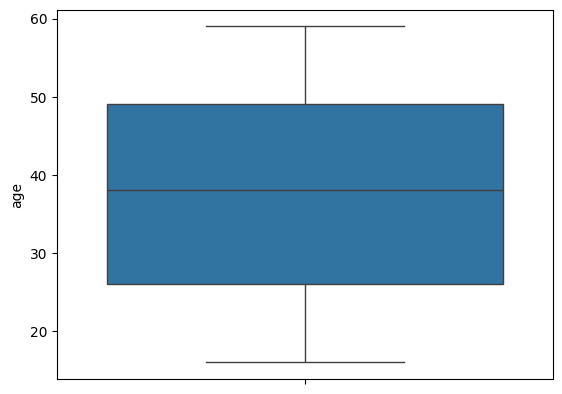

In [144]:
# Checking Outlier
sns.boxplot(df['age'])
plt.show()

In [145]:
df.gender.unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [146]:
df.drop_duplicates(inplace=True)

### Column Rename

In [147]:
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


In [148]:
change_countryname={
  'AU': 'Australia',
  'CA': 'Canada',
  'US': 'United States',
  'IN': 'India',
  'DE': 'Germany',
  'UK': 'United Kingdom',
  'PK': 'Pakistan',
  'FR': 'France'
}
change_countryname

{'AU': 'Australia',
 'CA': 'Canada',
 'US': 'United States',
 'IN': 'India',
 'DE': 'Germany',
 'UK': 'United Kingdom',
 'PK': 'Pakistan',
 'FR': 'France'}

In [149]:
df['country']=df['country'].map(change_countryname).fillna(df['country'])

In [150]:
Target_variable ={
    0:"Active",
    1:"Churned"
}
Target_variable

{0: 'Active', 1: 'Churned'}

In [151]:
df["is_churned"]=df["is_churned"].map(Target_variable).fillna(df["is_churned"])

In [152]:
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,Canada,Free,26,23,0.20,Desktop,31,0,Churned
1,2,Other,33,Germany,Family,141,62,0.34,Web,0,1,Active
2,3,Male,38,Australia,Premium,199,38,0.04,Mobile,0,1,Churned
3,4,Female,22,Canada,Student,36,2,0.31,Mobile,0,1,Active
4,5,Other,29,United States,Family,250,57,0.36,Mobile,0,1,Churned
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,Germany,Student,237,36,0.30,Mobile,0,1,Churned
7996,7997,Male,34,Australia,Premium,61,64,0.59,Mobile,0,1,Active
7997,7998,Female,17,United States,Free,81,62,0.33,Desktop,5,0,Active
7998,7999,Female,34,India,Student,245,94,0.27,Desktop,0,1,Active


# 📈 Exploratory Data Analysis

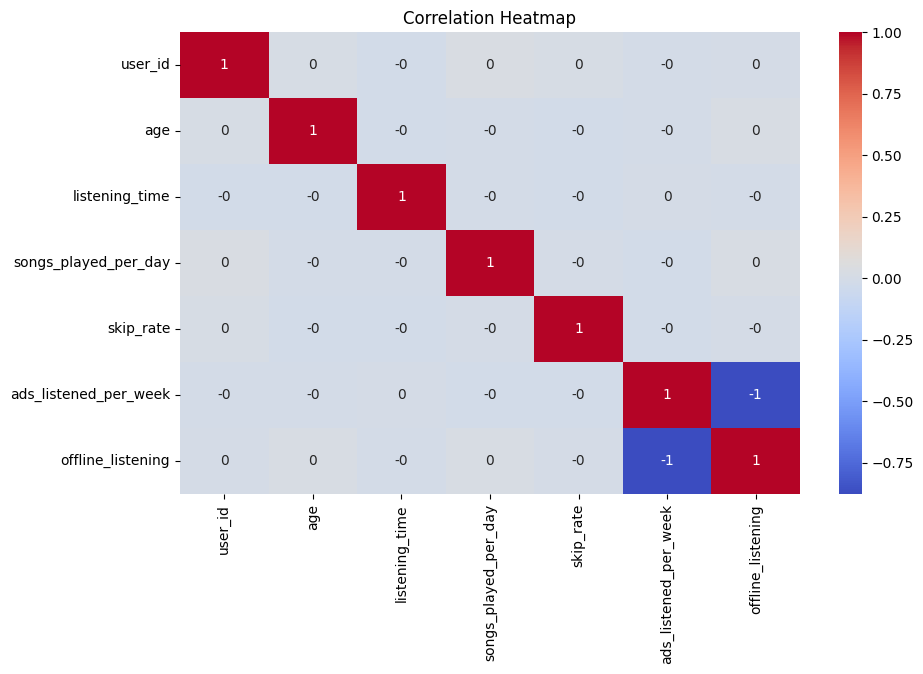

In [153]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,fmt=".0f",annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## **Country Wise Subscription**

In [154]:
country_wise_subs = df.groupby('country')['gender'].count().sort_values(ascending=False)

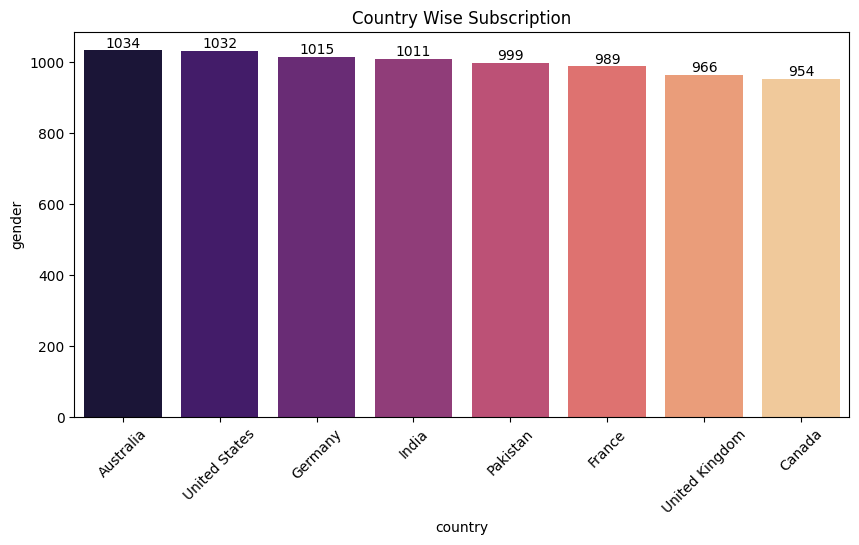

In [155]:
plt.figure(figsize=(10,5))
ax = sns.barplot(country_wise_subs,palette='magma')
for container in ax.containers:
    plt.bar_label(container)
plt.title("Country Wise Subscription")
plt.xticks(rotation=45)
plt.show()

## **Gender Wise Subscription**

In [156]:
df.groupby("subscription_type")["gender"].count()

subscription_type
Family     1908
Free       2018
Premium    2115
Student    1959
Name: gender, dtype: int64

In [157]:
sub_group=df.groupby(['subscription_type','gender'])['gender'].count()
sub_group

subscription_type  gender
Family             Female    604
                   Male      657
                   Other     647
Free               Female    687
                   Male      659
                   Other     672
Premium            Female    701
                   Male      725
                   Other     689
Student            Female    667
                   Male      650
                   Other     642
Name: gender, dtype: int64

In [158]:
pivot = sub_group.unstack(level="gender")
pivot

gender,Female,Male,Other
subscription_type,,,
Family,604,657,647
Free,687,659,672
Premium,701,725,689
Student,667,650,642


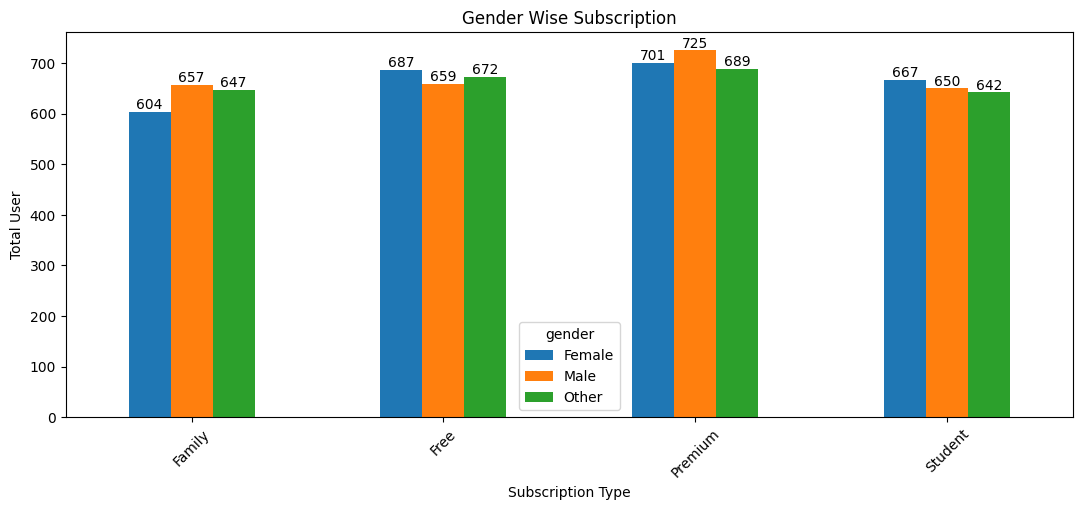

In [159]:
ax = pivot.plot(kind="bar", figsize=(13,5))
plt.title("Gender Wise Subscription")
plt.xlabel("Subscription Type")
plt.ylabel("Total User")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## Insight:
Across all subscription types—Family, Free, Premium, and Student—the number of users is fairly balanced across genders, with no major gaps. Male users tend to have slightly higher counts in most categories, particularly in the Premium and Family plans, while Female users show strong representation in the Free and Student plans. “Other” gender users also follow a similar pattern with consistently steady counts. Overall, subscription preferences appear broadly similar across genders, with only small variations.

## Gender wise user average age 

In [160]:
avg_age=df.groupby("gender")["age"].median()
avg_age

gender
Female    39.0
Male      37.0
Other     38.0
Name: age, dtype: float64

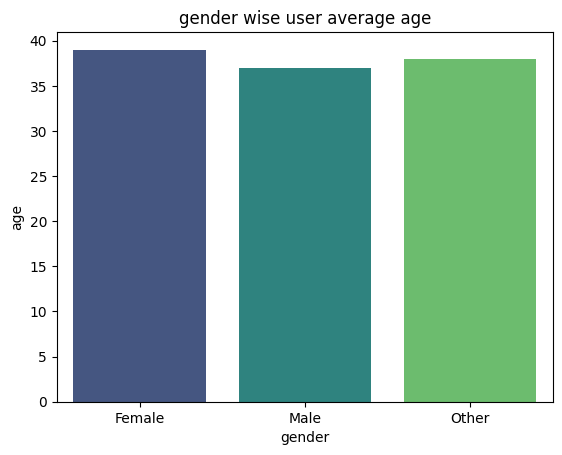

In [161]:
sns.barplot(avg_age,palette="viridis")
plt.title("gender wise user average age")
plt.show()

## Which device type is associated with the highest usage?

## Mobile vs Desktop vs Web

In [162]:
highest_usage = df['device_type'].value_counts()
highest_usage

device_type
Desktop    2778
Web        2623
Mobile     2599
Name: count, dtype: int64

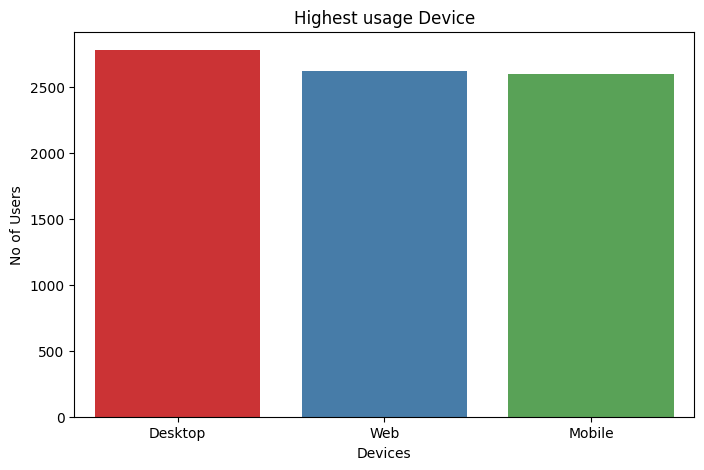

In [163]:
plt.figure(figsize=(8,5))
sns.barplot(highest_usage,palette="Set1")
plt.title("Highest usage Device")
plt.xlabel("Devices")
plt.ylabel("No of Users")
plt.show()

## Insight:

Desktop users show the highest overall usage (2,778), slightly exceeding Web (2,623) and Mobile (2,599). Although all three device types have similar usage levels, Desktop leads by a small margin, suggesting users may engage more deeply or for longer sessions when using desktop devices compared to mobile or web platforms.

## **Highest User Rate (by Gender)**

In [164]:
df3 = df['gender'].value_counts().round(2)
df3

gender
Male      2691
Female    2659
Other     2650
Name: count, dtype: int64

In [165]:
per = (df3.values/8000*100).round(2)
per

array([33.64, 33.24, 33.12])

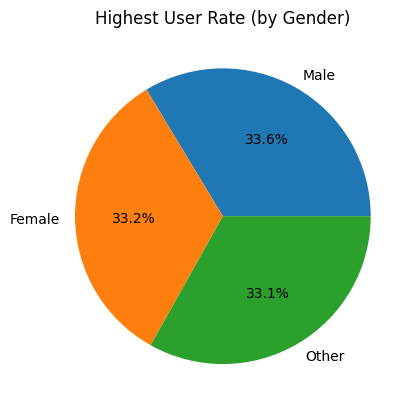

In [166]:
plt.pie(per,autopct="%1.1f%%",labels=df3.index)
plt.title("Highest User Rate (by Gender)")
plt.show()

## Insight:

Male users have the highest usage rate at 33.6%, followed closely by female users at 33.2% and other genders at 33.1%. The differences between the groups are minimal, indicating that usage is fairly evenly distributed across all genders.

## **How does subscription type affect listening behavior?**

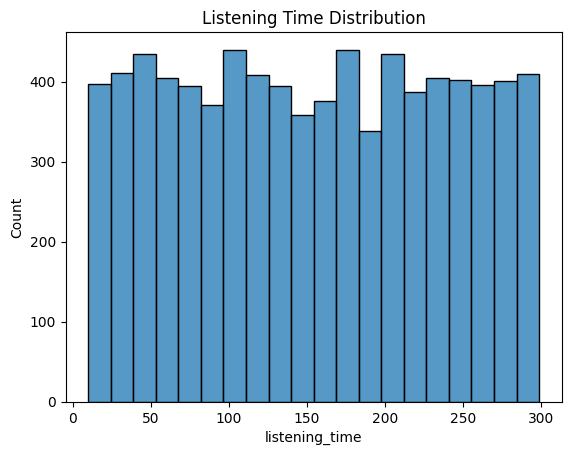

In [167]:
sns.histplot(df["listening_time"])
plt.title('Listening Time Distribution')
plt.show()

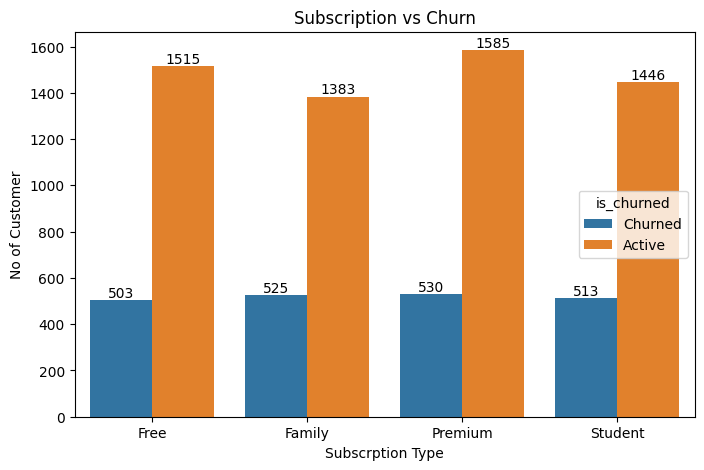

In [200]:
plt.figure(figsize=(8,5))
ax=sns.countplot(x="subscription_type", hue="is_churned", data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Subscription vs Churn")
plt.xlabel("Subscrption Type")
plt.ylabel("No of Customer")
plt.show()

## Compare average listening time

In [169]:
df.groupby('subscription_type')['listening_time'].mean().round(2)

subscription_type
Family     151.04
Free       155.00
Premium    155.52
Student    154.49
Name: listening_time, dtype: float64

##  Compare songs played per day

In [170]:
df.groupby('subscription_type')["songs_played_per_day"].mean().round(2)

subscription_type
Family     50.38
Free       49.20
Premium    49.74
Student    51.24
Name: songs_played_per_day, dtype: float64

## Compare skip rate

In [171]:
df.groupby('subscription_type')["skip_rate"].mean().round(2) 

subscription_type
Family     0.3
Free       0.3
Premium    0.3
Student    0.3
Name: skip_rate, dtype: float64

## **What is the relationship between skip rate and listening engagement?**

**Do users who skip more listen less?**

In [172]:
df.head(10)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,Canada,Free,26,23,0.20,Desktop,31,0,Churned
1,2,Other,33,Germany,Family,141,62,0.34,Web,0,1,Active
2,3,Male,38,Australia,Premium,199,38,0.04,Mobile,0,1,Churned
3,4,Female,22,Canada,Student,36,2,0.31,Mobile,0,1,Active
4,5,Other,29,United States,Family,250,57,0.36,Mobile,0,1,Churned
5,6,Female,17,Australia,Free,219,35,0.46,Desktop,13,0,Active
6,7,Female,39,United Kingdom,Premium,289,44,0.38,Desktop,0,1,Active
7,8,Female,41,United Kingdom,Free,210,68,0.11,Mobile,5,0,Active
8,9,Other,55,Germany,Student,50,66,0.29,Web,0,1,Active
9,10,Male,44,Germany,Free,278,94,0.38,Mobile,44,0,Active


In [173]:
data1=df[['listening_time','skip_rate']]

In [174]:
rel = data1.corr()
rel

,listening_time,skip_rate
listening_time,1.000000,-0.013603
skip_rate,-0.013603,1.000000


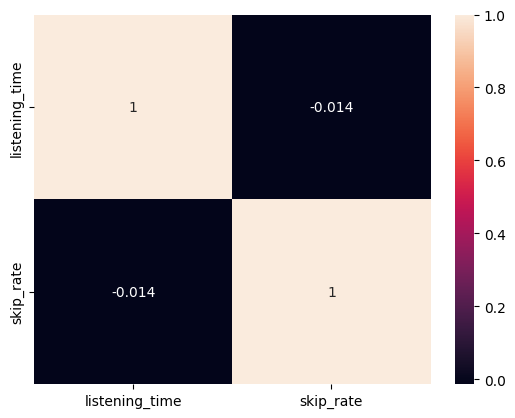

In [175]:
sns.heatmap(rel,annot=True)
plt.title("")
plt.show()

##  Do users who skip more listen less

In [207]:
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned,skip_category
0,1,Female,54,Canada,Free,26,23,0.20,Desktop,31,0,Churned,Medium
1,2,Other,33,Germany,Family,141,62,0.34,Web,0,1,Active,Medium
2,3,Male,38,Australia,Premium,199,38,0.04,Mobile,0,1,Churned,Low
3,4,Female,22,Canada,Student,36,2,0.31,Mobile,0,1,Active,Medium
4,5,Other,29,United States,Family,250,57,0.36,Mobile,0,1,Churned,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,Germany,Student,237,36,0.30,Mobile,0,1,Churned,Medium
7996,7997,Male,34,Australia,Premium,61,64,0.59,Mobile,0,1,Active,High
7997,7998,Female,17,United States,Free,81,62,0.33,Desktop,5,0,Active,Medium
7998,7999,Female,34,India,Student,245,94,0.27,Desktop,0,1,Active,Medium


In [209]:
skip_rate=df.groupby("subscription_type")['skip_rate'].median().round(2)
skip_rate

subscription_type
Family     0.30
Free       0.30
Premium    0.29
Student    0.30
Name: skip_rate, dtype: float64

## **Are premium-based users more engaged than free users?**

In [210]:
premium_based = df.groupby('subscription_type')[[
    'listening_time',
    'songs_played_per_day',
    'skip_rate'
]].mean().round(2)

premium_based

,listening_time,songs_played_per_day,skip_rate
subscription_type,,,
Family,151.04,50.38,0.3
Free,155.00,49.20,0.3
Premium,155.52,49.74,0.3
Student,154.49,51.24,0.3


## Insight:
Premium users show only a slight increase in listening time (155.52) compared to Free users (155.00), indicating that Premium users are marginally more engaged. However, the difference is very small, and listening times across all subscription types (Family, Free, Premium, Student) are nearly the same. This suggests that subscription type does not strongly influence overall listening time.

## **Customer Retention Analysis**

In [179]:
is_churned=df["is_churned"].value_counts()
is_churned

is_churned
Active     5929
Churned    2071
Name: count, dtype: int64

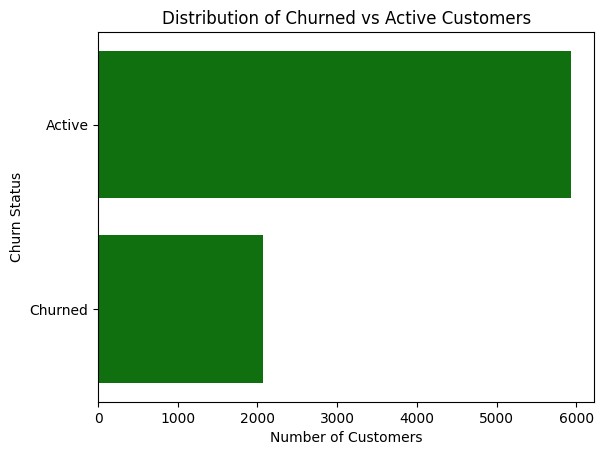

In [180]:
sns.barplot(is_churned,orient='h',color="green")
plt.title("Distribution of Churned vs Active Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Status")
plt.show()

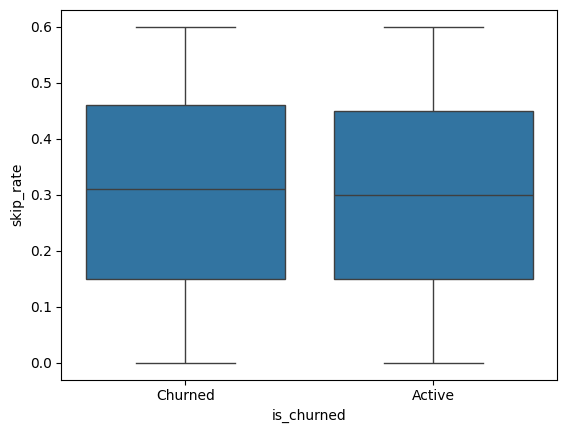

In [181]:
sns.boxplot(x="is_churned", y="skip_rate", data=df)
plt.show()

## **Does churn relate to listening activity?**

In [182]:
df.head(10)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned,skip_category
0,1,Female,54,Canada,Free,26,23,0.20,Desktop,31,0,Churned,Medium
1,2,Other,33,Germany,Family,141,62,0.34,Web,0,1,Active,Medium
2,3,Male,38,Australia,Premium,199,38,0.04,Mobile,0,1,Churned,Low
3,4,Female,22,Canada,Student,36,2,0.31,Mobile,0,1,Active,Medium
4,5,Other,29,United States,Family,250,57,0.36,Mobile,0,1,Churned,Medium
5,6,Female,17,Australia,Free,219,35,0.46,Desktop,13,0,Active,High
6,7,Female,39,United Kingdom,Premium,289,44,0.38,Desktop,0,1,Active,Medium
7,8,Female,41,United Kingdom,Free,210,68,0.11,Mobile,5,0,Active,Low
8,9,Other,55,Germany,Student,50,66,0.29,Web,0,1,Active,Medium
9,10,Male,44,Germany,Free,278,94,0.38,Mobile,44,0,Active,Medium


## **Compare listening time**
Look at their average listening time.

Then look at the average listening time of non-churned users.

Compare both to see who listens more.

In [204]:
avg_lis_churn=df.loc[(df['is_churned'] == "Churned"),"listening_time"]
print("Average Listening Time Churned User",
      avg_lis_churn)

Average Listening Time Churned User 0        26
2       199
4       250
11      113
14      114
       ... 
7981    253
7982    176
7984    277
7988    137
7995    237
Name: listening_time, Length: 2071, dtype: int64


In [206]:
avg_lis_nonchur=df.loc[(df['is_churned'] == "Active"),"listening_time"]
print("Average Listening Time Non-Churned User",
      avg_lis_nonchur)

Average Listening Time Non-Churned User 1       141
3        36
5       219
6       289
7       210
       ... 
7994     21
7996     61
7997     81
7998    245
7999    210
Name: listening_time, Length: 5929, dtype: int64


In [185]:
avg_lis_chur_rate=avg_lis_chur.mean().round(2)
print("Avg listening rate (Churned):", avg_lis_chur_rate)

Avg listening rate (Churned): 152.98


In [186]:
avg_lis_nonchur_rate=avg_lis_nonchur.mean().round(2)
print("Avg listening rate (Non-Churned):", avg_lis_nonchur_rate)

Avg listening rate (Non-Churned): 154.45


## **Higher skip rates?**

What is the average skip rate for churned users?

What is the average skip rate for active (non-churned) users?

In [197]:
avg_skip_chur=df.loc[(df['is_churned'] == "Churned"),"skip_rate"]
avg_skip_chur.mean().round(2)

np.float64(0.3)

In [199]:
avg_skip_nonchur=df.loc[(df['is_churned'] == "Active"),"skip_rate"]
avg_skip_nonchur.mean()

np.float64(0.29847360431776015)

In [190]:
avg_skip_rate_churn=avg_skip_chur.mean().round(2)
print("Avg skip rate (Churned):", avg_skip_rate_churn)

Avg skip rate (Churned): 0.3


In [191]:
avg_skip_rate=avg_skip_nonchur.mean().round(3)
print("Avg skip rate (Non-Churned):", avg_skip_rate)

Avg skip rate (Non-Churned): 0.298


## **Compare songs played per day**
How many songs per day churned users play

How many songs per day non-churned users play

In [192]:
avg_song_play_chur=df.loc[(df['is_churned'] == "Churned"),"songs_played_per_day"]

In [194]:
avg_song_play_nonchur=df.loc[(df['is_churned'] == "Active"),"songs_played_per_day"]

In [195]:
avg_churn_user = avg_song_play_chur.mean().round(2)
print("Avg songs per day (Churned):", avg_churn_user)

Avg songs per day (Churned): 50.58


In [196]:
avg_churn_nonuser = avg_song_play_nonchur.mean().round(2)
print("Avg songs per day (Non-Churned):", avg_churn_nonuser)

Avg songs per day (Non-Churned): 49.97


# Conclusion:

This analysis examined user listening behavior, subscription types, and engagement patterns to identify factors influencing churn. The results show that user engagement is the strongest driver of retention.

Users with higher listening time and lower skip rates are less likely to churn, while users with low activity and high skip rates are more likely to leave. Subscription type and device usage showed minimal impact on churn compared to engagement metrics.

###  💡 Key Takeaway

Improving music recommendations, reducing skip rates, and targeting low-engagement users can help Spotify reduce churn and improve user retention.